# 03. Exploratory Data Analysis

In [68]:
# Color theme
color_blue  = "#4545d1"  
color_green = "#45d145" 
color_red   = "#d14545"  
color_grey  = "#808080" 

# 3.1 Data exploration for baseline model
In this notebook, we conduct an exploratory data analysis for the baseline model, whose variables include Hour, Day, Month, Public Holiday, School Holiday, Site, Direction (in and out), Hour × Day, and Hour × Direction. We also examine the important external continuous variable Fuel Price.

First, we check for missing values and find that there are no missing values among these variables. We then examine the counts for each variable and find that Hour, Day, Month, Site, and Direction are relatively balanced in their distributions. In contrast, Public Holiday and School Holiday show a more imbalanced pattern, with fewer cyclist counts during holiday periods. As for Fuel Price, its distribution lies within a moderate range, and fuel prices fluctuate over time.

Then, for the response variable (count_rescaled), the distribution is highly concentrated at low values and strongly right-skewed, with many zero values. Finally, we examine the correlations among the variables. The positive Spearman correlation indicates that cyclist traffic tends to be higher in later time intervals, but the relationship is not purely linear and should therefore be analysed through the full count model rather than through correlation alone.

### Import packages

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### Load data

In [70]:
project_folder = Path("..")
processed_folder = project_folder / "data" / "processed"
eda_folder = processed_folder / "eda_model1"
eda_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Blues")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv(processed_folder / "model_development_data.csv", parse_dates=["date", "installation_date"])

### Identify category variables and interaction terms

In [71]:
# Standardize / rename variables for EDA
df["hour_bin"] = df["hour_bin"]
df["weekday"] = pd.Categorical(
    df["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
df["month"] = pd.Categorical(
    df["month"],
    categories=list(range(1, 13)),
    ordered=True
)
df["is_public_holiday"]= pd.Categorical(
    df["is_public_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
df["is_school_holiday"] = pd.Categorical(
    df["is_school_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
df["site_id"] = df["site_id"].astype(str)
df["direction"] = pd.Categorical(
    df["direction"]
)

# Interaction terms
df["hour_day"] = df["hour_bin"].astype(str) + "_" + df["weekday"].astype(str)
df["hour_direction"] = df["hour_bin"].astype(str) + "_" + df["direction"].astype(str)

In [72]:
print({df.shape[1]})

{30}


### Missing value check for categorical variables and interaction terms

In [73]:
model_vars = [
    "hour_bin", "weekday", "month", "is_public_holiday", "is_school_holiday",
    "site_id", "direction", "hour_day", "hour_direction"
]

missing_summary = (
    df[model_vars]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["missing_pct"] = missing_summary["missing_n"] / len(df)

missing_summary.to_csv(eda_folder / "missing_summary_model1.csv", index=False)
missing_summary

,variable,missing_n,missing_pct
0,hour_bin,0,0.0
1,weekday,0,0.0
2,month,0,0.0
3,is_public_holiday,0,0.0
4,is_school_holiday,0,0.0
5,site_id,0,0.0
6,direction,0,0.0
7,hour_day,0,0.0
8,hour_direction,0,0.0


### Counts summary table and plots for categorical variables

In [74]:
# Summary table

def make_count_summary(data, var_name):
    s = data[var_name]
    tab = s.value_counts(dropna=False)
    total_n = len(s)
    nonmissing_n = s.notna().sum()
    missing_n = s.isna().sum()
    n_levels = s.nunique(dropna=True)
    max_share = (tab.iloc[0] / total_n) if len(tab) > 0 else np.nan
    min_share = (tab.iloc[-1] / total_n) if len(tab) > 0 else np.nan

    return pd.DataFrame({
        "variable": [var_name],
        "total_n": [total_n],
        "nonmissing_n": [nonmissing_n],
        "missing_n": [missing_n],
        "missing_share": [missing_n / total_n],
        "n_levels": [n_levels],
        "largest_level_n": [tab.iloc[0] if len(tab) > 0 else np.nan],
        "largest_level_share": [max_share],
        "smallest_level_n": [tab.iloc[-1] if len(tab) > 0 else np.nan],
        "smallest_level_share": [min_share]
    })

summary_vars = [
    "hour_bin", "weekday", "month", "is_public_holiday",
    "is_school_holiday", "direction", "site_id",
    "hour_day", "hour_direction"
]

counts_summary_compact = pd.concat(
    [make_count_summary(df, v) for v in summary_vars],
    ignore_index=True
)

counts_summary_compact.to_csv(eda_folder / "counts_summary_compact.csv", index=False)
counts_summary_compact

,variable,total_n,nonmissing_n,missing_n,missing_share,n_levels,largest_level_n,largest_level_share,smallest_level_n,smallest_level_share
0,hour_bin,3361867,3361867,0,0.0,12,280299,0.083376,279294,0.083077
1,weekday,3361867,3361867,0,0.0,7,481988,0.143369,479080,0.142504
2,month,3361867,3361867,0,0.0,12,302638,0.090021,239058,0.071109
3,is_public_holiday,3361867,3361867,0,0.0,2,3235787,0.962497,126080,0.037503
4,is_school_holiday,3361867,3361867,0,0.0,2,2401389,0.714302,960478,0.285698
5,direction,3361867,3361867,0,0.0,2,1680936,0.500001,1680931,0.499999
6,site_id,3361867,3361867,0,0.0,141,26298,0.007822,854,0.000254
7,hour_day,3361867,3361867,0,0.0,84,40184,0.011953,39224,0.011667
8,hour_direction,3361867,3361867,0,0.0,24,140150,0.041688,139647,0.041539


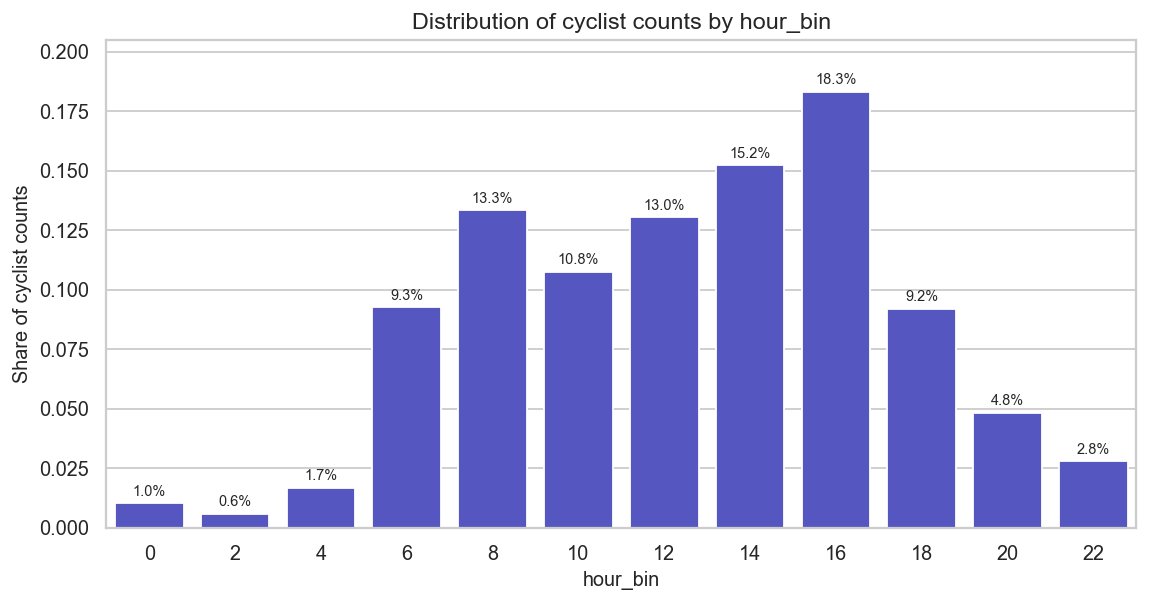

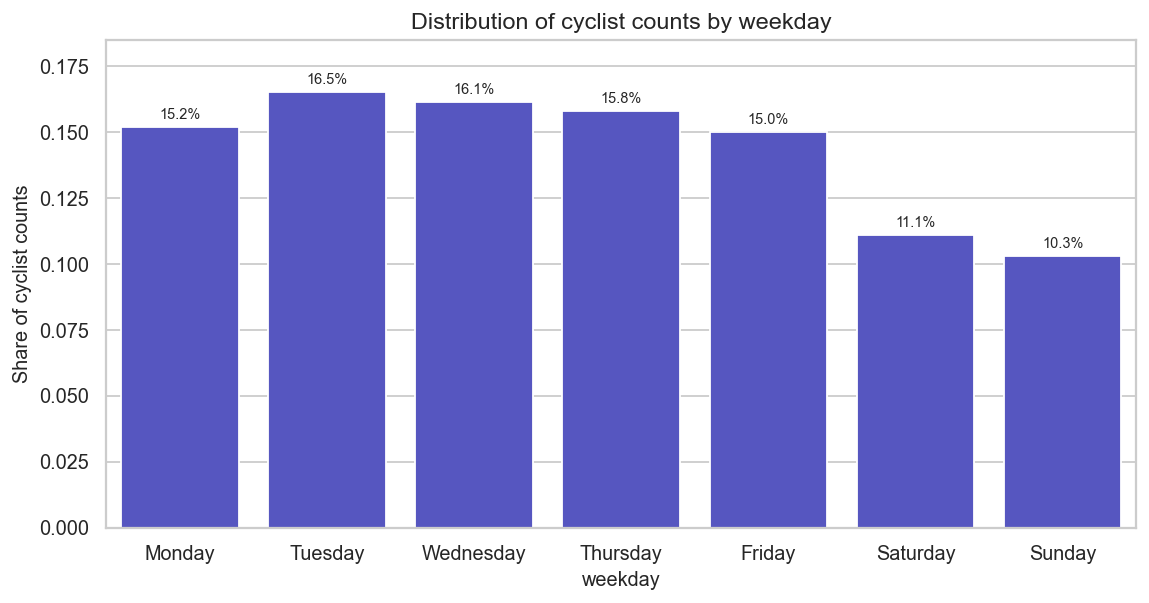

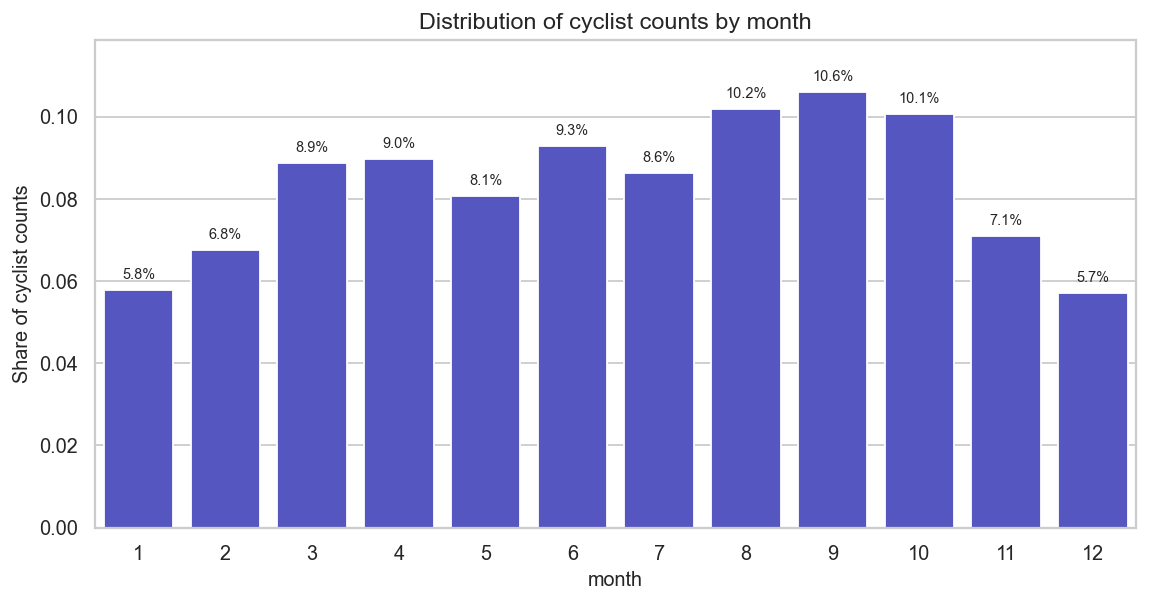

In [75]:
# Ordered bar charts: hour_bin / weekday / month

ordered_vars = {
    "hour_bin": list(sorted(df["hour_bin"].dropna().unique())),
    "weekday": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    "month": list(range(1, 13))
}

for var_name, order in ordered_vars.items():
    plot_df = (
        df.groupby(var_name, dropna=False, observed=False)["count_rescaled"]
        .sum()
        .reindex(order)
        .rename_axis("level")
        .reset_index(name="n")
    )
    plot_df["share"] = plot_df["n"] / plot_df["n"].sum()

    plt.figure(figsize=(9, 4.8))
    ax = sns.barplot(data=plot_df, x="level", y="share", color="#4545d1")
    ax.set_title(f"Distribution of cyclist counts by {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Share of cyclist counts")
    ax.set_ylim(0, plot_df["share"].max() * 1.12)

    for i, v in enumerate(plot_df["share"]):
        ax.text(i, v + 0.002, f"{v:.1%}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(eda_folder / f"{var_name.lower()}_cyclistcount_share_bar.png", bbox_inches="tight")
    plt.show()
    plt.close()

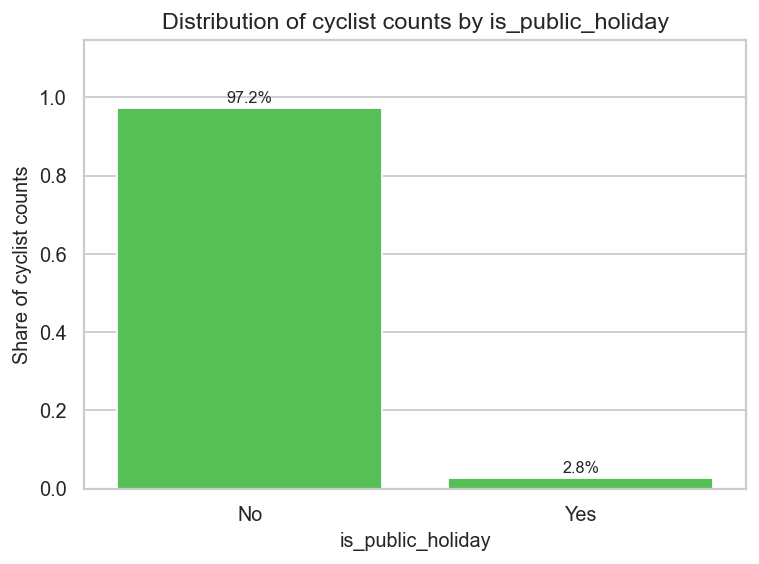

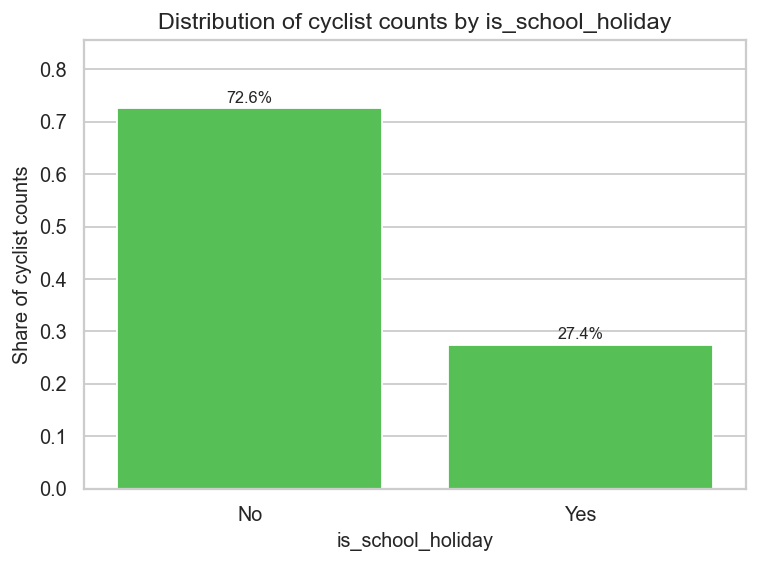

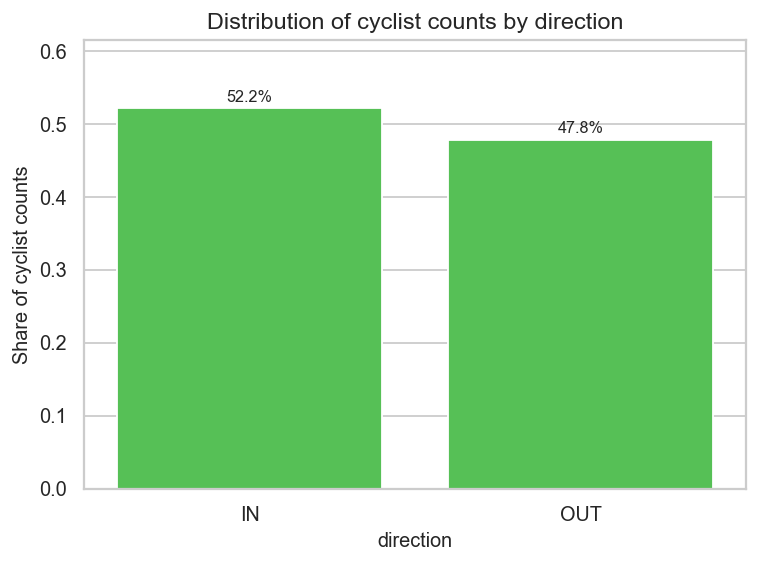

In [76]:
# Binary bar charts: Public_holiday / School_holiday / Direction

binary_vars = ["is_public_holiday", "is_school_holiday", "direction"]

for var_name in binary_vars:
    plot_df = (
        df.groupby(var_name, dropna=False, observed=False)["count_rescaled"]
        .sum()
        .rename_axis("level")
        .reset_index(name="n")
    )
    plot_df["share"] = plot_df["n"] / plot_df["n"].sum()

    plt.figure(figsize=(6, 4.5))
    ax = sns.barplot(data=plot_df, x="level", y="share", color="#45d145")
    ax.set_title(f"Distribution of cyclist counts by {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Share of cyclist counts")
    ax.set_ylim(0, plot_df["share"].max() * 1.18)

    for i, v in enumerate(plot_df["share"]):
        ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(eda_folder / f"{var_name.lower()}_cyclistcount_share_bar.png", bbox_inches="tight")
    plt.show()
    plt.close()

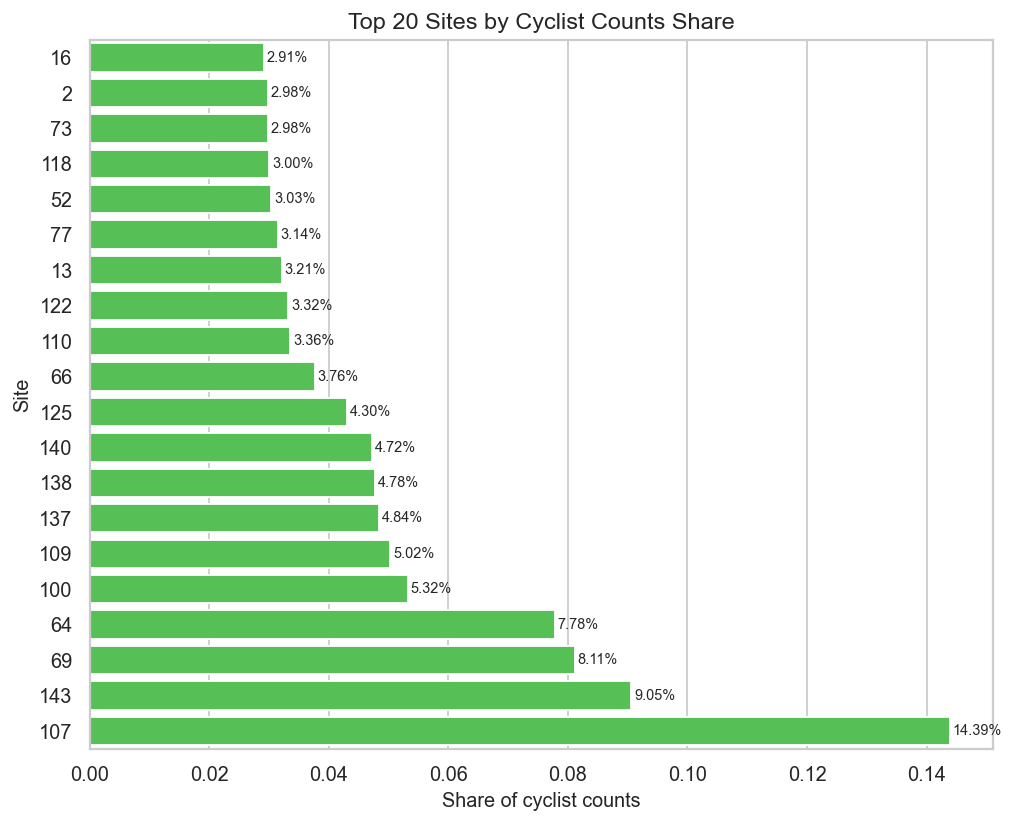

In [77]:
# Top-20 bar chart for site_id

ttop_n = 20

site_plot_df = (
    df.groupby("site_id", dropna=False, observed=False)["count_rescaled"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .sort_values(ascending=True)
    .rename_axis("level")
    .reset_index(name="n")
)

site_plot_df["share"] = site_plot_df["n"] / site_plot_df["n"].sum()

plt.figure(figsize=(8, 6.5))
ax = sns.barplot(data=site_plot_df, x="share", y="level", color="#45d145")
ax.set_title(f"Top {top_n} Sites by Cyclist Counts Share")
ax.set_xlabel("Share of cyclist counts")
ax.set_ylabel("Site")

for i, v in enumerate(site_plot_df["share"]):
    ax.text(v + 0.0005, i, f"{v:.2%}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(eda_folder / "site_top20_cyclistcounts_bar.png", bbox_inches="tight")
plt.show()
plt.close()

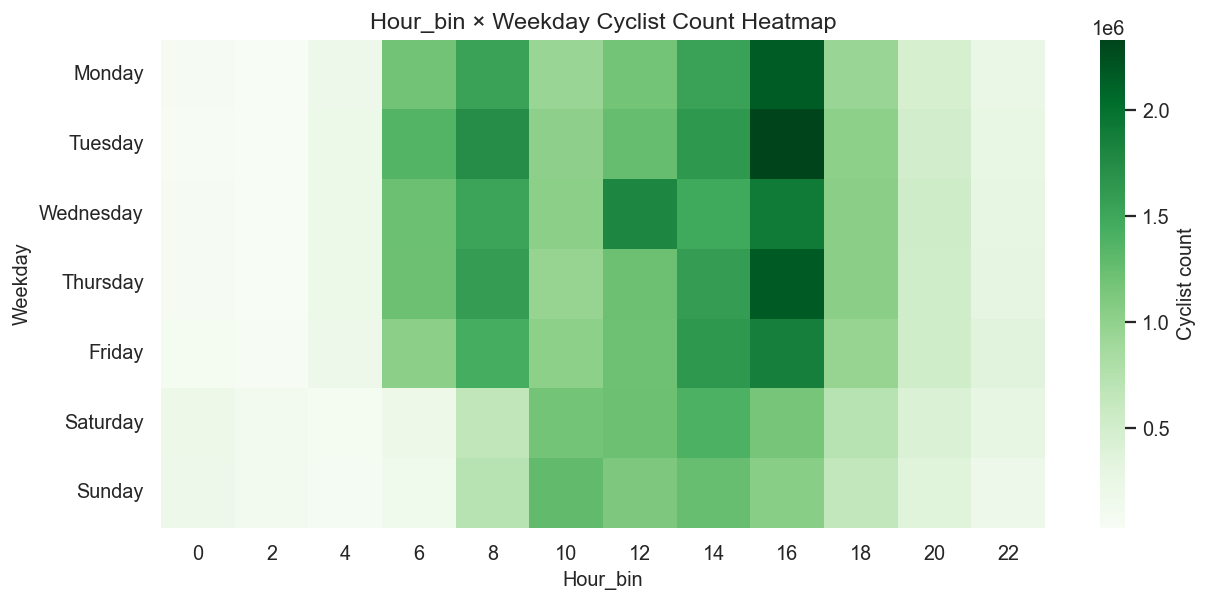

In [78]:
# Heatmap for Hour_bin × Weekday using cyclist counts

hour_day_heatmap = (
    df
    .groupby(["weekday", "hour_bin"], observed=False)["count"]
    .sum()
    .unstack(fill_value=0)
)

hour_day_heatmap = hour_day_heatmap.reindex(
    index=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

hour_day_heatmap = hour_day_heatmap.reindex(
    columns=sorted(hour_day_heatmap.columns)
)

plt.figure(figsize=(10, 4.8))
sns.heatmap(hour_day_heatmap, cmap="Greens", cbar_kws={"label": "Cyclist count"})
plt.title("Hour_bin × Weekday Cyclist Count Heatmap")
plt.xlabel("Hour_bin")
plt.ylabel("Weekday")
plt.tight_layout()
plt.savefig(eda_folder / "hour_day_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

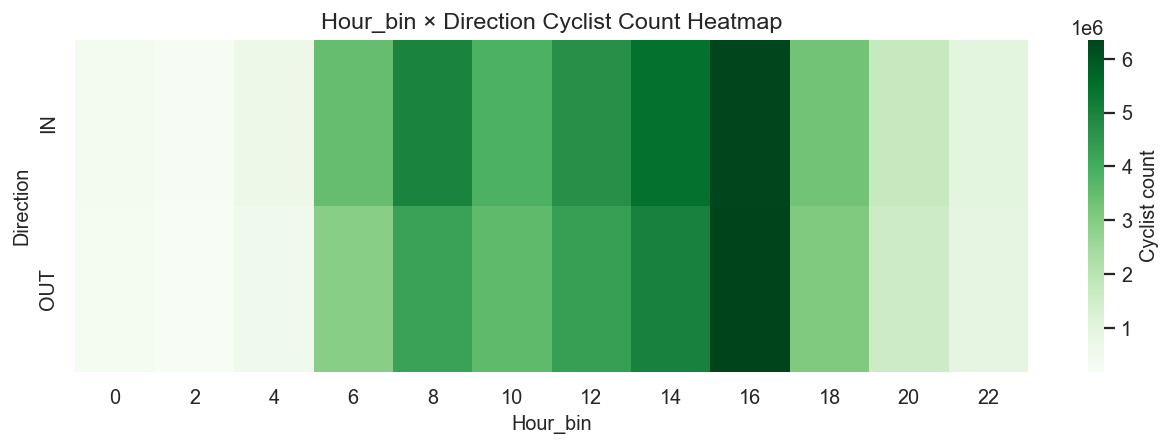

In [79]:
# Heatmap for Hour_bin × Direction using cyclist counts (sum)

hour_direction_heatmap = (
    df
    .groupby(["direction", "hour_bin"], observed=False)["count"]
    .sum()
    .unstack(fill_value=0)
)

hour_direction_heatmap = hour_direction_heatmap.reindex(
    columns=sorted(hour_direction_heatmap.columns)
)

plt.figure(figsize=(10, 3.6))
sns.heatmap(hour_direction_heatmap, cmap="Greens", cbar_kws={"label": "Cyclist count"})
plt.title("Hour_bin × Direction Cyclist Count Heatmap")
plt.xlabel("Hour_bin")
plt.ylabel("Direction")
plt.tight_layout()
plt.savefig(eda_folder / "hour_direction_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

### Data exploration for Fuel prices

In [80]:
df["fuel_price_petrol_95_rounded"] = df["fuel_price_petrol_95"].round(2)

# Basic count 

fuel_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "unique_values_row_level"
    ],
    "value": [
        len(df),
        df["fuel_price_petrol_95_rounded"].notna().sum(),
        df["fuel_price_petrol_95_rounded"].isna().sum(),
        df["fuel_price_petrol_95_rounded"].isna().mean(),
        df["fuel_price_petrol_95_rounded"].nunique()
    ]
})

fuel_count_summary.to_csv(eda_folder / "fuelprice_count_summary.csv", index=False)
fuel_count_summary

,metric,value
0,total_rows,3361867.0
1,non_missing_rows,3361867.0
2,missing_rows,0.0
3,missing_share,0.0
4,unique_values_row_level,47.0


In [81]:
# Daily-level fuel price data
fuel_daily = (
    df[["date", "fuel_price_petrol_95_rounded"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

fuel_daily_summary = pd.DataFrame({
    "metric": [
        "unique_days",
        "non_missing_days",
        "missing_days",
        "unique_values_daily_level"
    ],
    "value": [
        len(fuel_daily),
        fuel_daily["fuel_price_petrol_95_rounded"].notna().sum(),
        fuel_daily["fuel_price_petrol_95_rounded"].isna().sum(),
        fuel_daily["fuel_price_petrol_95_rounded"].nunique()
    ]
})

fuel_daily_summary.to_csv(eda_folder / "fuelprice_daily_summary.csv", index=False)
fuel_daily_summary

,metric,value
0,unique_days,1096
1,non_missing_days,1096
2,missing_days,0
3,unique_values_daily_level,47


In [82]:
# Binned counts table

n_bins = 20

fuel_daily_nonmissing = fuel_daily.dropna(subset=["fuel_price_petrol_95_rounded"])

fuel_daily_nonmissing["fuelprice_bin"] = pd.cut(
    fuel_daily_nonmissing["fuel_price_petrol_95_rounded"],
    bins=n_bins
)

fuel_bin_counts = (
    fuel_daily_nonmissing["fuelprice_bin"]
    .value_counts(sort=False)
    .rename_axis("FuelPrice_bin")
    .reset_index(name="n")
)

fuel_bin_counts["share"] = fuel_bin_counts["n"] / fuel_bin_counts["n"].sum()

fuel_bin_counts.to_csv(eda_folder / "fuelprice_binned_counts.csv", index=False)
fuel_bin_counts

,FuelPrice_bin,n,share
0,"(1.509, 1.54]",31,0.028285
1,"(1.54, 1.57]",84,0.076642
2,"(1.57, 1.6]",133,0.121350
3,"(1.6, 1.63]",105,0.095803
4,"(1.63, 1.66]",77,0.070255
5,"(1.66, 1.69]",147,0.134124
6,"(1.69, 1.72]",168,0.153285
7,"(1.72, 1.75]",91,0.083029
8,"(1.75, 1.78]",35,0.031934
9,"(1.78, 1.81]",56,0.051095


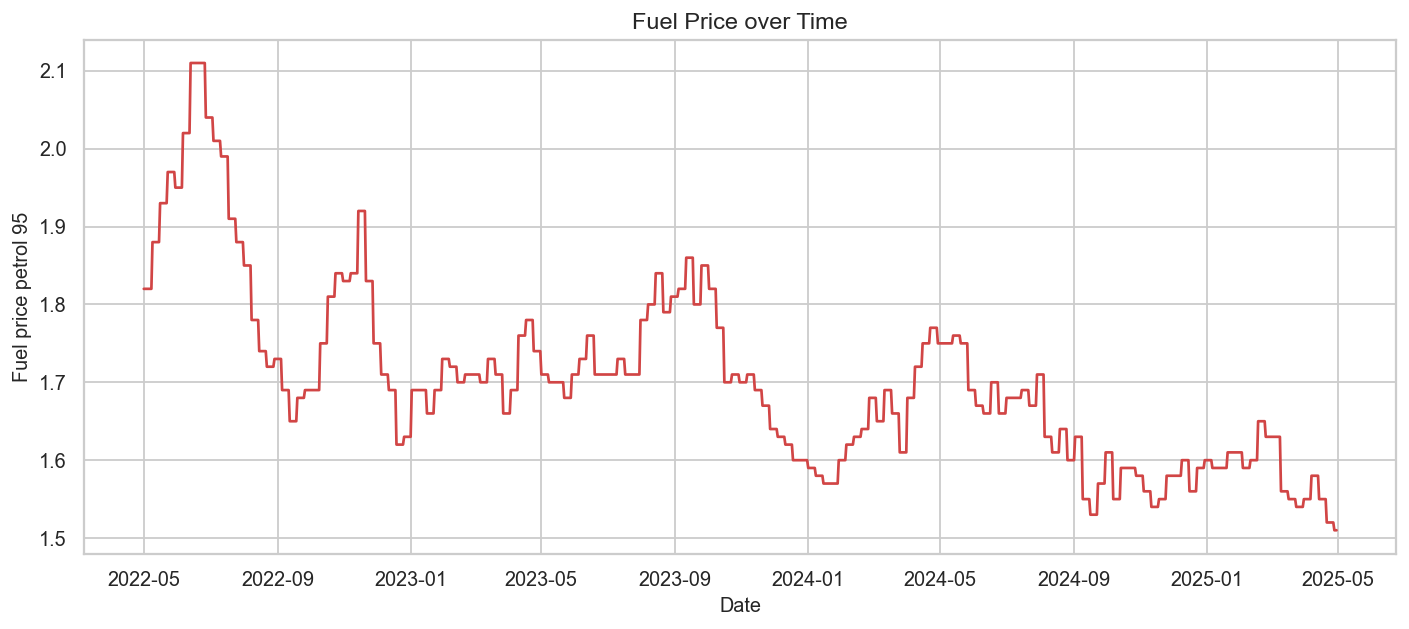

In [83]:
# Time-series plot

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=fuel_daily_nonmissing,
    x="date",
    y="fuel_price_petrol_95_rounded",
    color=color_red
)
plt.title("Fuel Price over Time")
plt.xlabel("Date")
plt.ylabel("Fuel price petrol 95")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_time_series.png", bbox_inches="tight")
plt.show()
plt.close()

In [84]:
# Descriptive statistics

fuel_desc = (
    fuel_daily_nonmissing["fuel_price_petrol_95_rounded"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
fuel_desc.columns = ["statistic", "value"]

fuel_desc.to_csv(eda_folder / "fuelprice_descriptive_stats.csv", index=False)
fuel_desc

,statistic,value
0,count,1096.000000
1,mean,1.702336
2,std,0.116711
3,min,1.510000
4,1%,1.530000
5,5%,1.550000
6,25%,1.610000
7,50%,1.690000
8,75%,1.750000
9,95%,1.950000


### Data exploration for response variable (count_rescaled)

In [85]:
response_var = "count_rescaled"
df["count_rescaled"] = df[response_var]

# Basic count

response_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "zero_rows",
        "zero_share",
        "unique_values"
    ],
    "value": [
        len(df),
        df["count_rescaled"].notna().sum(),
        df["count_rescaled"].isna().sum(),
        df["count_rescaled"].isna().mean(),
        (df["count_rescaled"] == 0).sum(),
        (df["count_rescaled"] == 0).mean(),
        df["count_rescaled"].nunique()
    ]
})

response_count_summary.to_csv(eda_folder / "response_count_summary.csv", index=False)
response_count_summary

,metric,value
0,total_rows,3.361867e+06
1,non_missing_rows,3.361867e+06
2,missing_rows,0.000000e+00
3,missing_share,0.000000e+00
4,zero_rows,9.330100e+05
5,zero_share,2.775273e-01
6,unique_values,1.040000e+03


There is no missing value in count_rescaled, but many 0 values.

In [86]:
# Binned counts table

n_bins = 30

response_nonmissing = df.dropna(subset=["count_rescaled"])

response_nonmissing["count_rescaled_bin"] = pd.cut(
    response_nonmissing["count_rescaled"],
    bins=n_bins
)

response_bin_counts = (
    response_nonmissing["count_rescaled_bin"]
    .value_counts(sort=False)
    .rename_axis("count_rescaled_bin")
    .reset_index(name="n")
)

response_bin_counts["share"] = response_bin_counts["n"] / response_bin_counts["n"].sum()

response_bin_counts.to_csv(eda_folder / "response_binned_counts.csv", index=False)
response_bin_counts

,count_rescaled_bin,n,share
0,"(-8.682, 289.4]",3343408,9.945093e-01
1,"(289.4, 578.8]",16518,4.913341e-03
2,"(578.8, 868.2]",1720,5.116205e-04
3,"(868.2, 1157.6]",146,4.342825e-05
4,"(1157.6, 1447.0]",35,1.041088e-05
5,"(1447.0, 1736.4]",20,5.949075e-06
6,"(1736.4, 2025.8]",7,2.082176e-06
7,"(2025.8, 2315.2]",1,2.974538e-07
8,"(2315.2, 2604.6]",4,1.189815e-06
9,"(2604.6, 2894.0]",1,2.974538e-07


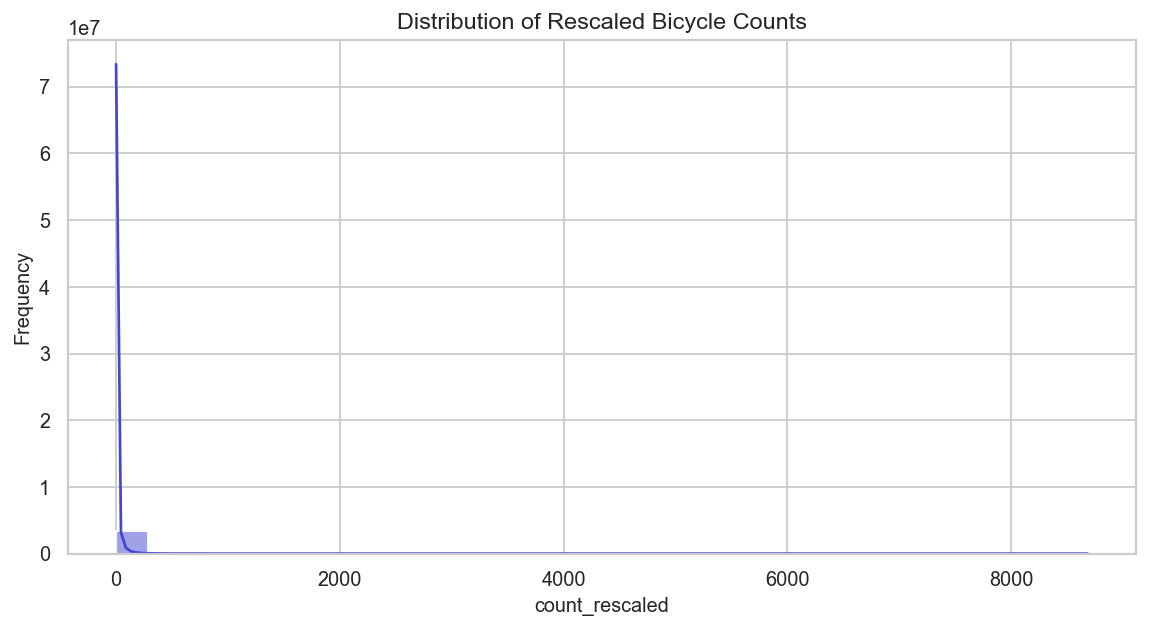

In [87]:
# Histogram + KDE

plt.figure(figsize=(9, 5))
sns.histplot(
    response_nonmissing["count_rescaled"],
    bins=30,
    kde=True,
    color=color_blue
)
plt.title("Distribution of Rescaled Bicycle Counts")
plt.xlabel("count_rescaled")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist.png", bbox_inches="tight")
plt.show()
plt.close()

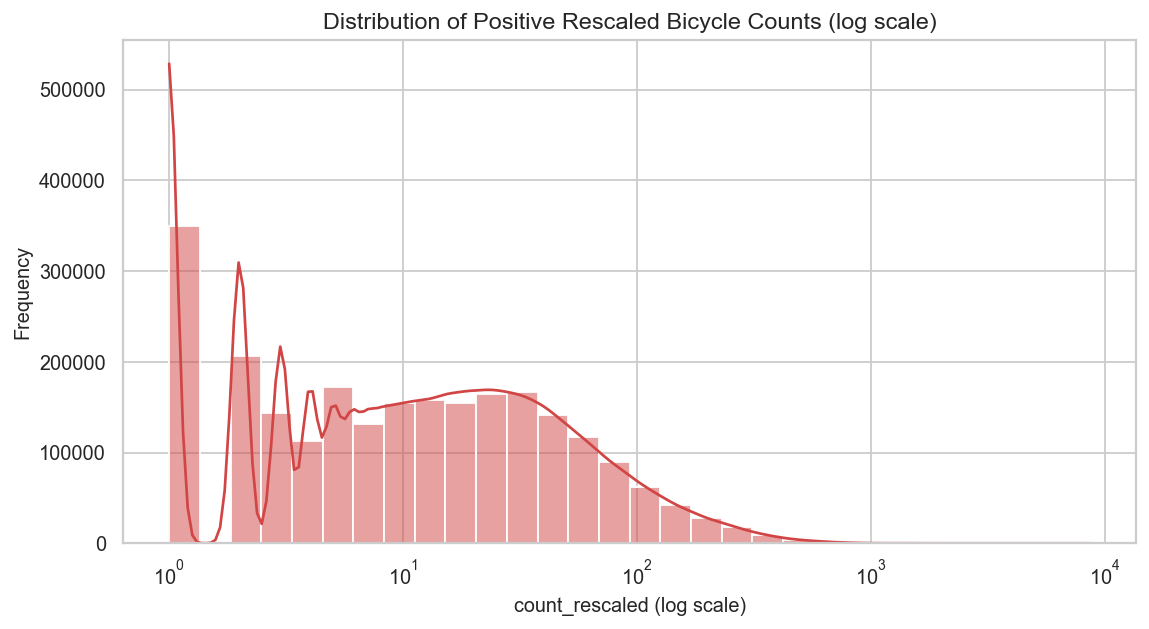

In [88]:
# log-scale histogram

response_positive = response_nonmissing[response_nonmissing["count_rescaled"] > 0]

plt.figure(figsize=(9, 5))
sns.histplot(
    response_positive["count_rescaled"],
    bins=30,
    kde=True,
    color=color_red,
    log_scale=True
)
plt.title("Distribution of Positive Rescaled Bicycle Counts (log scale)")
plt.xlabel("count_rescaled (log scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist_logscale.png", bbox_inches="tight")
plt.show()
plt.close()

In [89]:
# Descriptive statistics

response_desc = (
    response_nonmissing["count_rescaled"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
response_desc.columns = ["statistic", "value"]

response_desc.to_csv(eda_folder / "response_descriptive_stats.csv", index=False)
response_desc

,statistic,value
0,count,3.361867e+06
1,mean,2.059975e+01
2,std,4.777244e+01
3,min,0.000000e+00
4,1%,0.000000e+00
5,5%,0.000000e+00
6,25%,0.000000e+00
7,50%,4.000000e+00
8,75%,2.100000e+01
9,95%,9.300000e+01


# 3.2 Data exploration for 2025-2026 dataset and external factors

## Importing packages, establishing path and reading count data

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns

In [91]:
project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"
diagnostics_folder = project_folder / "outputs" / "diagnostics"

diagnostics_folder.mkdir(parents=True, exist_ok=True)

In [92]:
prediction_data = pd.read_csv(
    processed_folder / "prediction_data_with_factors.csv"
)

prediction_data.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,...,0.0,5.95,dry,0,0,No event,0,No event,0,No event
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,...,0.0,5.80,dry,0,0,No event,0,No event,0,No event
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,...,0.0,5.10,dry,0,0,No event,0,No event,0,No event
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,...,0.0,5.95,dry,0,0,No event,0,No event,0,No event
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,...,0.0,6.00,dry,0,0,No event,0,No event,0,No event


## Validation and structural check

In [93]:
print(f"Total Rows: {prediction_data.shape[0]}")
print(f"Total Columns: {prediction_data.shape[1]}")

Total Rows: 1177575
Total Columns: 44


In [94]:
prediction_data.dtypes

site_id                         int64
direction                      object
year                            int64
date                           object
month                           int64
weekday                        object
hour_bin                        int64
count                         float64
observed_intervals              int64
total_intervals                 int64
missing_intervals               int64
missing_share                 float64
expected_intervals_for_row      int64
count_rescaled                  int64
rescaled                        int64
longitude                     float64
latitude                      float64
site_name                      object
municipality                   object
district                       object
installation_date              object
direction_description          object
is_public_holiday               int64
holiday_name                   object
is_school_holiday               int64
school_holiday_name            object
fuel_price_p

In [95]:
pd.set_option("display.max_columns", None)
prediction_data.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,15.00,0.0,0.0,0.0,5.95,dry,0,0,No event,0,No event,0,No event
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,13.05,0.0,0.0,0.0,5.80,dry,0,0,No event,0,No event,0,No event
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,11.20,0.0,0.0,0.0,5.10,dry,0,0,No event,0,No event,0,No event
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,10.50,0.0,0.0,0.0,5.95,dry,0,0,No event,0,No event,0,No event
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,14.55,0.0,0.0,0.0,6.00,dry,0,0,No event,0,No event,0,No event


In [96]:
pd.set_option("display.max_columns", None)
prediction_data.tail()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
1177570,143,OUT,2026,2026-04-30,4,Thursday,14,385.0,8,8,0,0.0,8,385,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,19.80,0.0,0.0,0.0,19.00,dry,0,0,No event,0,No event,0,No event
1177571,143,OUT,2026,2026-04-30,4,Thursday,16,860.0,8,8,0,0.0,8,860,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,20.45,0.0,0.0,0.0,19.25,dry,0,0,No event,0,No event,0,No event
1177572,143,OUT,2026,2026-04-30,4,Thursday,18,394.0,8,8,0,0.0,8,394,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,20.35,0.0,0.0,0.0,19.20,dry,0,0,No event,0,No event,0,No event
1177573,143,OUT,2026,2026-04-30,4,Thursday,20,193.0,8,8,0,0.0,8,193,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,18.70,0.0,0.0,0.0,15.15,dry,0,0,No event,0,No event,0,No event
1177574,143,OUT,2026,2026-04-30,4,Thursday,22,144.0,8,8,0,0.0,8,144,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,16.10,0.0,0.0,0.0,15.40,dry,0,0,No event,0,No event,0,No event


In [97]:
date_columns = [
    "date",
    "installation_date"
]

for column in date_columns:
    if column in prediction_data.columns:
        prediction_data[column] = pd.to_datetime(
           prediction_data[column],
            errors="coerce"
        )

## Missing data check (Mostly for rechecking new-created columns)

In [98]:
prediction_data.isna().sum()

site_id                          0
direction                        0
year                             0
date                             0
month                            0
weekday                          0
hour_bin                         0
count                            0
observed_intervals               0
total_intervals                  0
missing_intervals                0
missing_share                    0
expected_intervals_for_row       0
count_rescaled                   0
rescaled                         0
longitude                        0
latitude                         0
site_name                        0
municipality                     0
district                      6562
installation_date                0
direction_description            0
is_public_holiday                0
holiday_name                     0
is_school_holiday                0
school_holiday_name              0
fuel_price_petrol_95             0
coord_combo                      0
geopy_municipality  

Reloading the dataset from csv file makes the "No event" values automatically become missing values. I recoded them below. 

In [99]:
event_type_columns = [
    'outdoor_music_event_type', 
    'indoor_music_event_type', 
    'sport_event_type'
]

for col in event_type_columns:
    if col in prediction_data.columns:
        prediction_data[col] = prediction_data[col].fillna("No event")

In [100]:
prediction_data.isna().sum()

site_id                          0
direction                        0
year                             0
date                             0
month                            0
weekday                          0
hour_bin                         0
count                            0
observed_intervals               0
total_intervals                  0
missing_intervals                0
missing_share                    0
expected_intervals_for_row       0
count_rescaled                   0
rescaled                         0
longitude                        0
latitude                         0
site_name                        0
municipality                     0
district                      6562
installation_date                0
direction_description            0
is_public_holiday                0
holiday_name                     0
is_school_holiday                0
school_holiday_name              0
fuel_price_petrol_95             0
coord_combo                      0
geopy_municipality  

## Defining variable groups

In [101]:
categorical_variables = [
    "weekday", "hour_bin", "month", 
    "geopy_region", "geopy_province", "geopy_municipality",
    "is_public_holiday", "holiday_name", "is_school_holiday", "school_holiday_name",
    "precipitation_category", 
    "is_strike", "is_outdoor_music", "outdoor_music_event_type",
    "is_indoor_music", "indoor_music_event_type", "is_sport_event", "sport_event_type"
]

continuous_variables = [
    "fuel_price_petrol_95",
    "temperature_mean",     
    "precipitation_sum", 
    "rain_sum", 
    "snowfall_sum", 
    "wind_speed_mean"
]

categorical_variables = [var for var in categorical_variables if var in prediction_data.columns]
continuous_variables = [var for var in continuous_variables if var in prediction_data.columns]

print(f"Tracking {len(categorical_variables)} Categorical Variables.")
print(f"Tracking {len(continuous_variables)} Continuous Variables.")

Tracking 18 Categorical Variables.
Tracking 6 Continuous Variables.


## Baseline Traffic Sanity Check

We don't use count_rescaled as our outcome variable anymore, I guess. But I will still conduct a brief check here to compare the distribution with the past data and consider it as a baseline.

In [102]:
prediction_data["count_rescaled"].describe()

count    1.177575e+06
mean     2.409010e+01
std      5.301450e+01
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+00
75%      2.500000e+01
max      4.740000e+03
Name: count_rescaled, dtype: float64

In [103]:
print("Minimum count:", prediction_data["count_rescaled"].min())
print("Maximum count:", prediction_data["count_rescaled"].max())
print("Mean count:", prediction_data["count_rescaled"].mean())
print("Median count:", prediction_data["count_rescaled"].median())
print("Share of zero counts:", (prediction_data["count_rescaled"] == 0).mean())

Minimum count: 0
Maximum count: 4740
Mean count: 24.090098719826763
Median count: 5.0
Share of zero counts: 0.25593104473175804


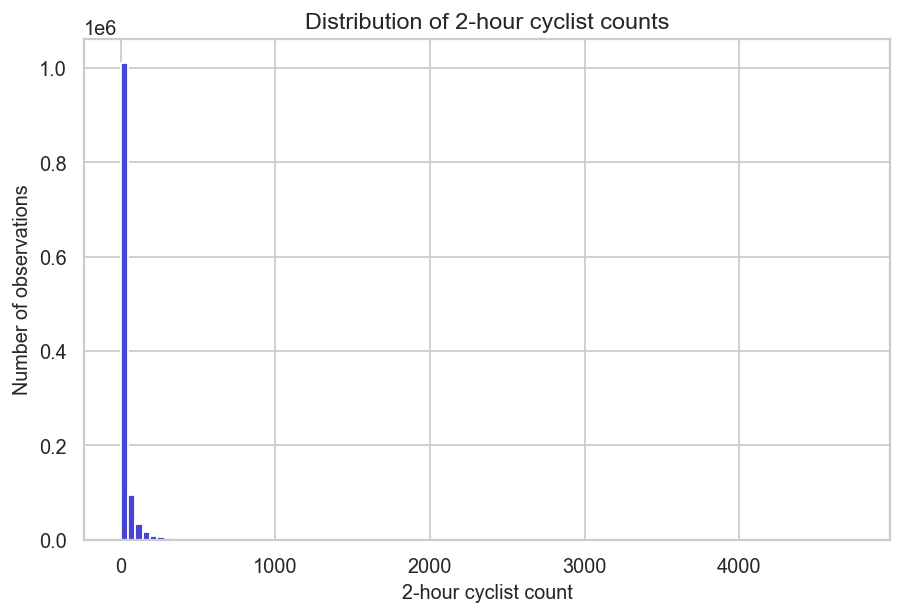

In [104]:
plt.figure(figsize=(8, 5))
plt.hist(prediction_data["count_rescaled"], bins=100, color=color_blue)
plt.title("Distribution of 2-hour cyclist counts")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

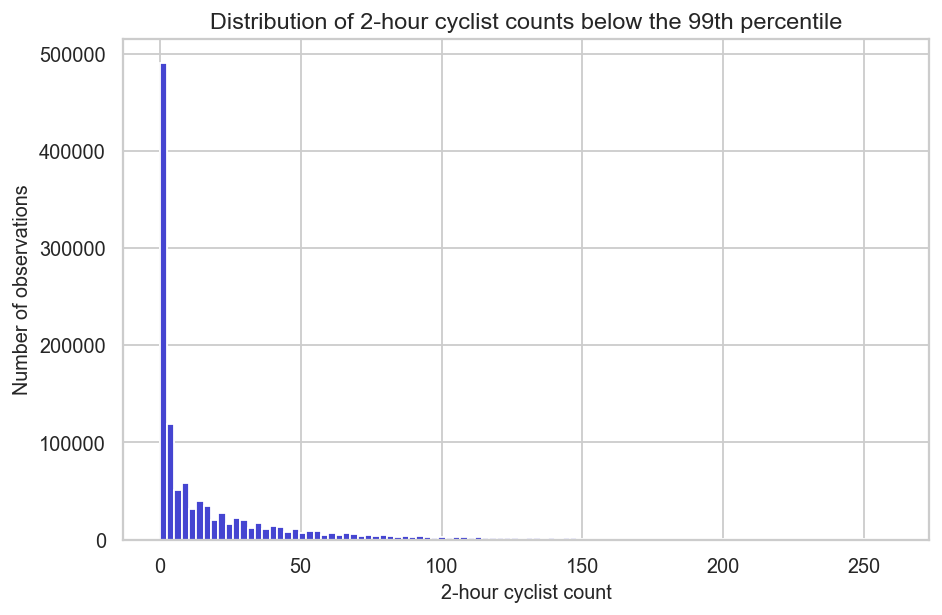

In [105]:
upper_limit = prediction_data["count_rescaled"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    prediction_data.loc[
        prediction_data["count_rescaled"] <= upper_limit,
        "count_rescaled"
    ],
    bins=100,
    color=color_blue
)
plt.title("Distribution of 2-hour cyclist counts below the 99th percentile")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

## Categorical predictors

In [106]:
# summary tables
def categorical_count_table(data, variable):
    table = (
        data[variable]
        .value_counts(dropna=False)
        .reset_index()
    )

    table.columns = [variable, "count"]
    table["percentage"] = 100 * table["count"] / len(data)

    return table

In [107]:
for variable in categorical_variables:
    print("\n" + "=" * 80)
    print(variable)
    display(categorical_count_table(prediction_data, variable).head(30))


weekday


,weekday,count,percentage
0,Thursday,171006,14.521878
1,Monday,167848,14.253699
2,Saturday,167821,14.251406
3,Friday,167805,14.250048
4,Tuesday,167763,14.246481
5,Wednesday,167741,14.244613
6,Sunday,167591,14.231875



hour_bin


,hour_bin,count,percentage
0,14,98164,8.336114
1,12,98163,8.336030
2,18,98162,8.335945
3,20,98162,8.335945
4,10,98160,8.335775
5,22,98160,8.335775
6,16,98159,8.335690
7,6,98156,8.335435
8,8,98153,8.335180
9,0,98150,8.334926



month


...

,indoor_music_event_type,count,percentage
0,No event,1177287,99.975543
1,indoor concert,150,0.012738
2,indoor music festival,54,0.004586
3,indoor electronic concert,48,0.004076
4,indoor orchestral concert,24,0.002038
5,musical concert/show,12,0.001019



is_sport_event


,is_sport_event,count,percentage
0,0,1175971,99.863788
1,1,1604,0.136212



sport_event_type


,sport_event_type,count,percentage
0,No event,1175971,99.863788
1,cycling participation event,648,0.055028
2,cyclocross race,432,0.036686
3,road cycling race,264,0.022419
4,cyclocross world cup,120,0.010190
5,road cycling stage race,96,0.008152
6,running event,44,0.003736


## Continuous predictors 

In [108]:
# summary statistics
prediction_data[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_price_petrol_95,1177575.0,1.569154,0.105046,1.4482,1.52342,1.54093,1.55825,1.8965
temperature_mean,1177575.0,12.085717,6.705686,-7.2000,7.30000,12.00000,16.65000,37.2000
precipitation_sum,1177575.0,0.149679,0.565626,0.0000,0.00000,0.00000,0.00000,19.6000
rain_sum,1177575.0,0.141433,0.546132,0.0000,0.00000,0.00000,0.00000,19.6000
snowfall_sum,1177575.0,0.005776,0.090623,0.0000,0.00000,0.00000,0.00000,10.7100
wind_speed_mean,1177575.0,12.601872,6.067722,0.1000,8.00000,11.85000,16.45000,51.4000


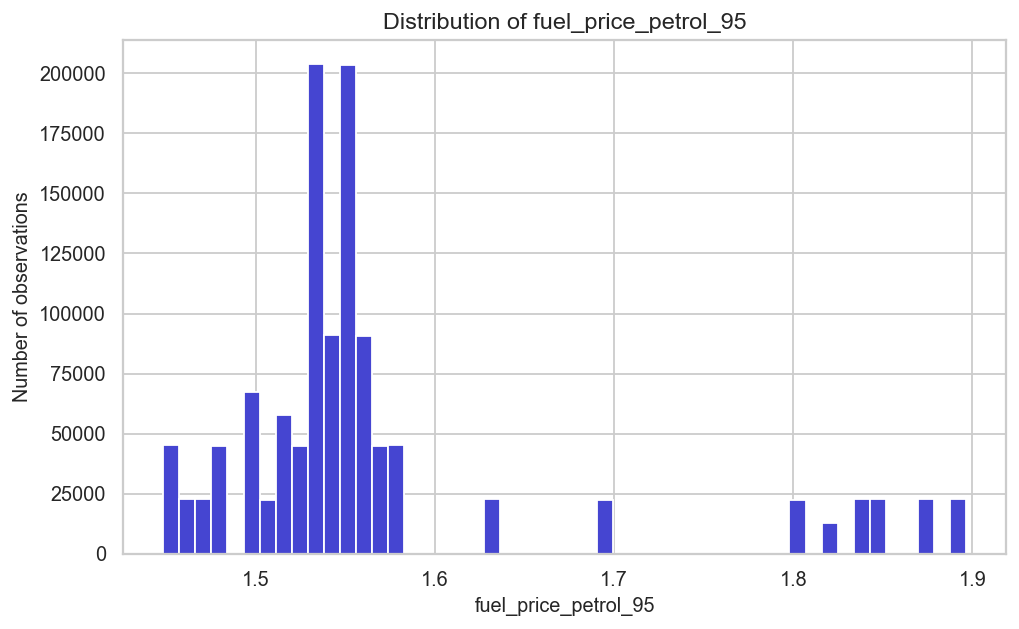

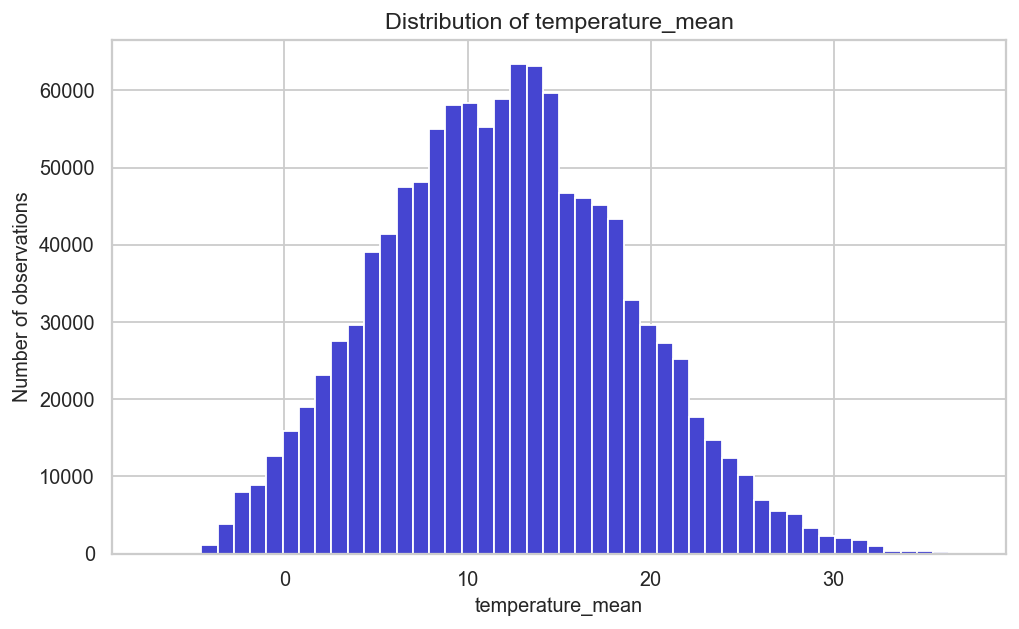

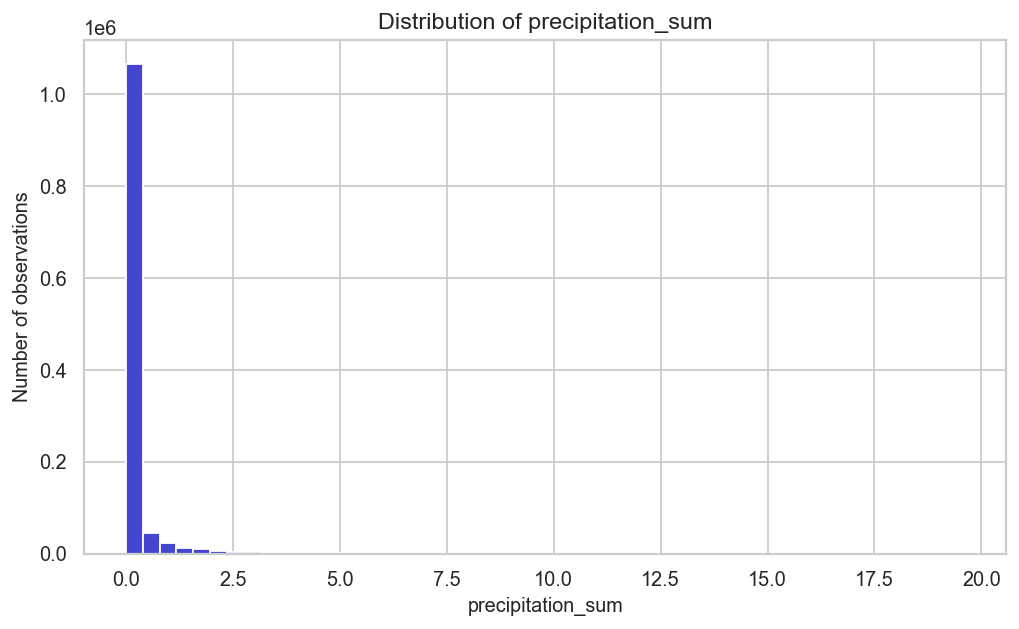

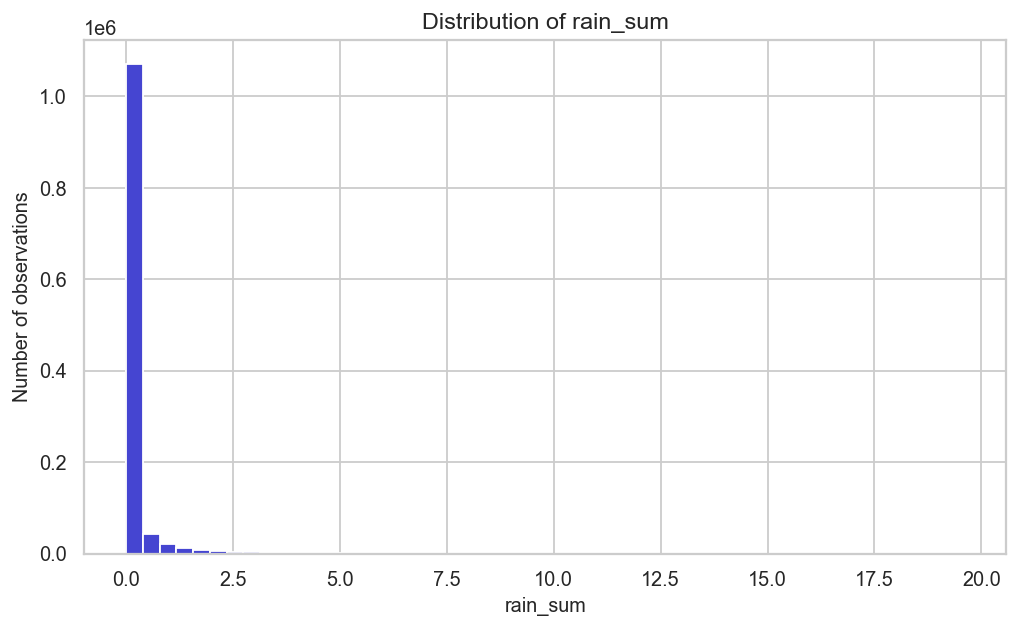

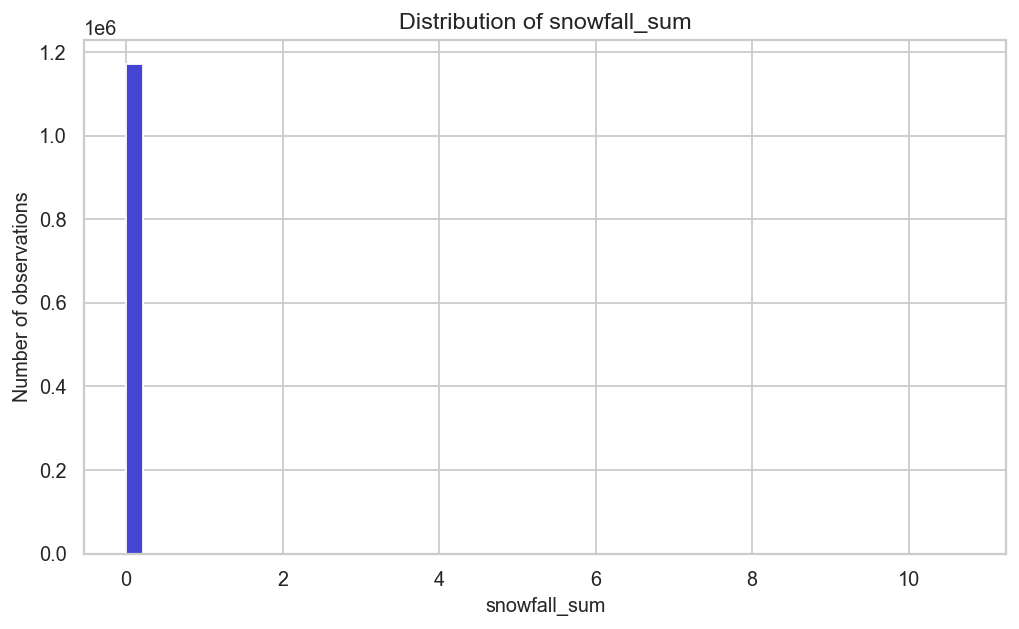

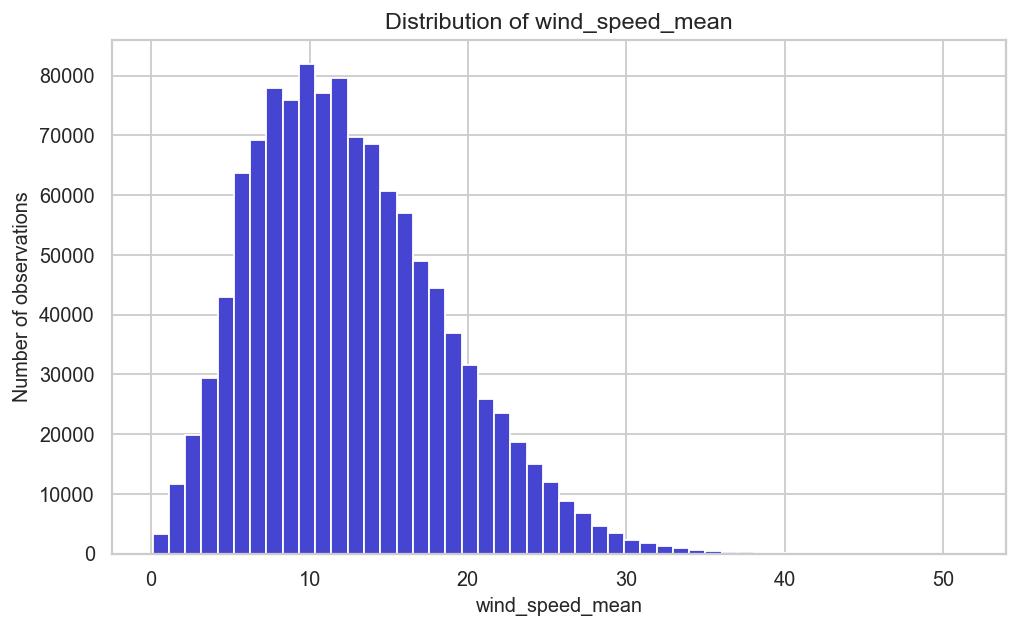

In [109]:
# Distribution plots
def plot_histogram(data, variable, bins=50, color=color_blue):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins, color=color)
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of observations")
    plt.tight_layout()
    plt.show()

for variable in continuous_variables:
    plot_histogram(prediction_data, variable)

## Weather factors' analysis

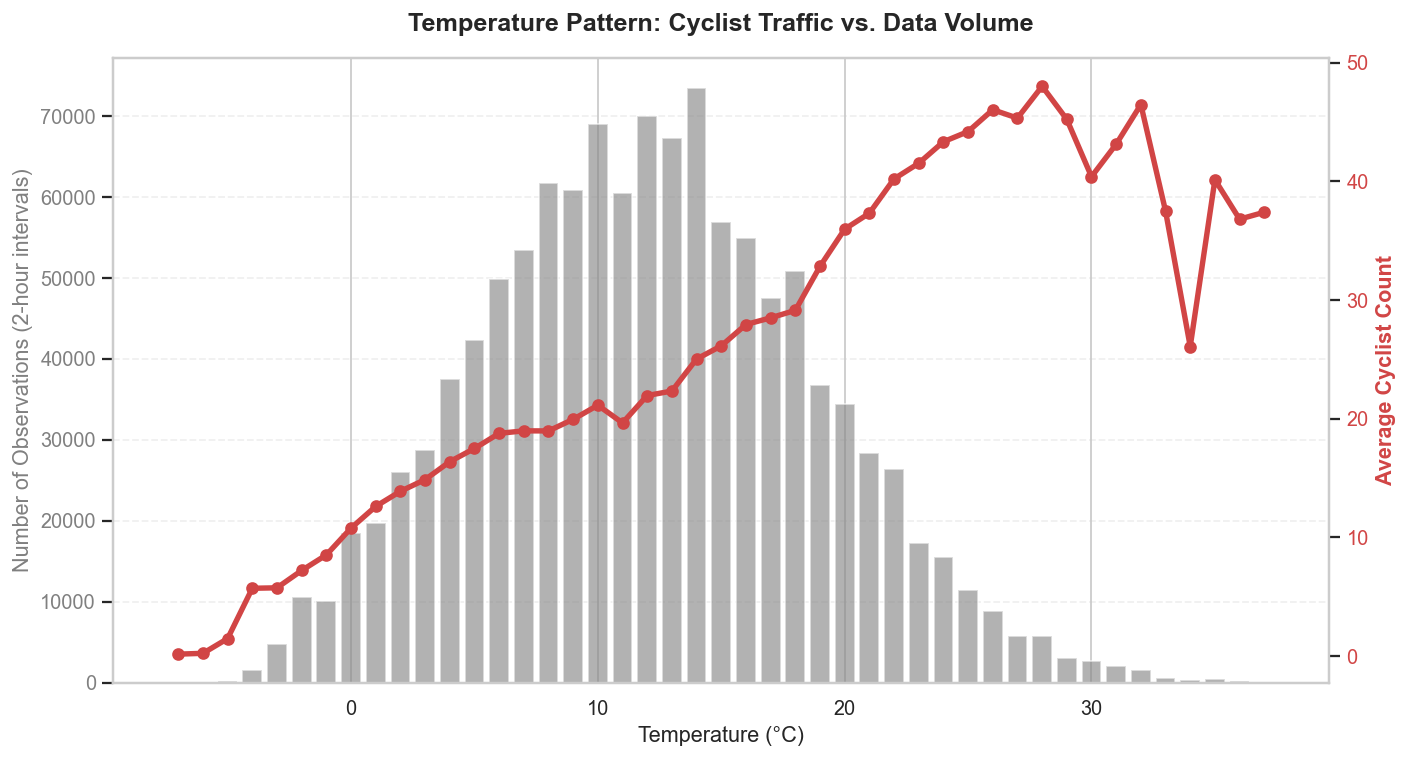

In [116]:
# Temperature impact

prediction_data['temp_rounded'] = prediction_data['temperature_mean'].round()


temp_summary = prediction_data.groupby('temp_rounded').agg(
    num_obs=('count_rescaled', 'count'),    # Counts how many 2-hour intervals occurred
    avg_traffic=('count_rescaled', 'mean')  # Calculates the average traffic
).reset_index()


fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.bar(
    temp_summary['temp_rounded'], 
    temp_summary['num_obs'], 
    color=color_grey, 
    alpha=0.6, 
    label='Data Volume'
)
ax1.set_xlabel("Temperature (°C)", fontsize=12)
ax1.set_ylabel("Number of Observations (2-hour intervals)", color=color_grey, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_grey)

ax2 = ax1.twinx()

ax2.plot(
    temp_summary['temp_rounded'], 
    temp_summary['avg_traffic'], 
    color=color_red, 
    linewidth=3, 
    marker='o', 
    label='Avg Cyclists'
)
ax2.set_ylabel("Average Cyclist Count", color=color_red, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_red)

plt.title("Temperature Pattern: Cyclist Traffic vs. Data Volume", pad=15, fontsize=14, fontweight='bold')

ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax2.grid(False)
fig.tight_layout()
plt.show()

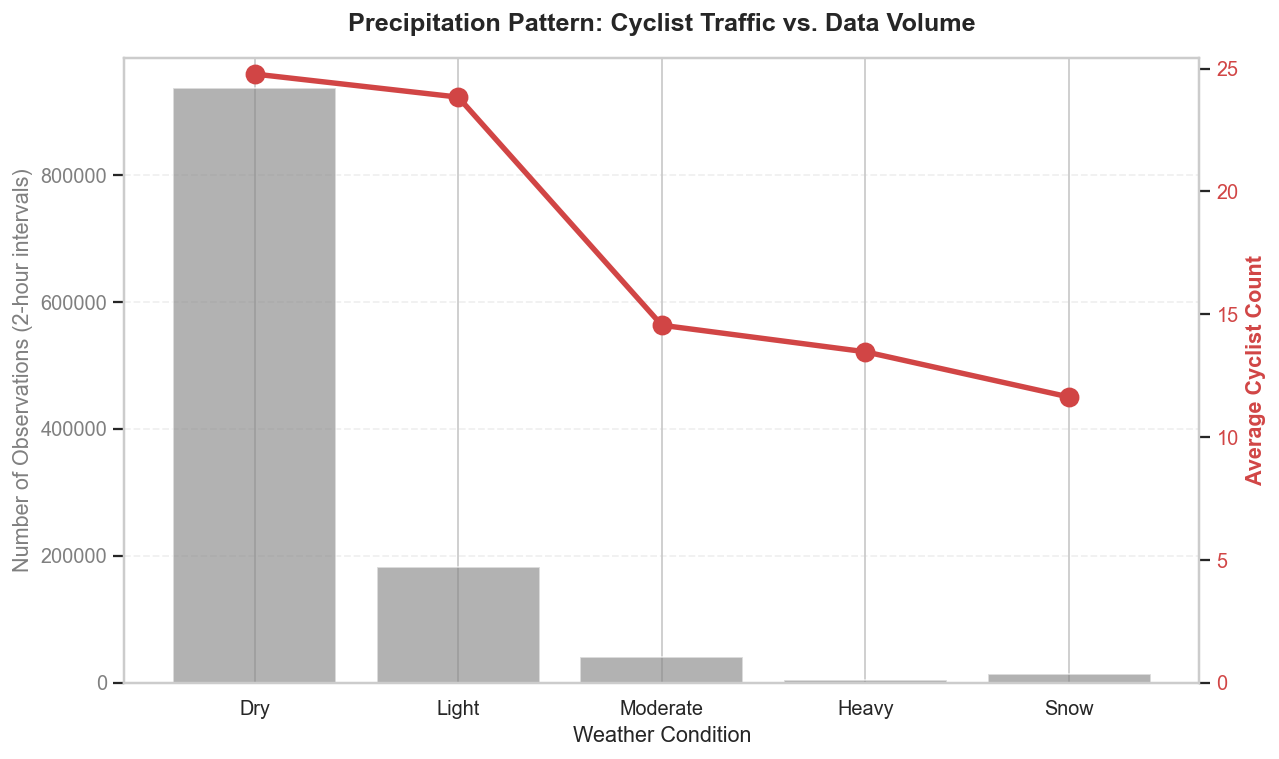

In [115]:
# Precipitation impact

precip_order = ['dry', 'light_precipitation', 'moderate_precipitation', 'heavy_precipitation', 'snow']
precip_summary = prediction_data.groupby('precipitation_category').agg(
    num_obs=('count_rescaled', 'count'),
    avg_traffic=('count_rescaled', 'mean')
)

precip_summary = precip_summary.reindex(precip_order).reset_index()
precip_summary['display_label'] = precip_summary['precipitation_category'].str.replace('_precipitation', '').str.title()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    precip_summary['display_label'], 
    precip_summary['num_obs'], 
    color=color_grey, 
    alpha=0.6, 
    label='Data Volume'
)
ax1.set_xlabel("Weather Condition", fontsize=12)
ax1.set_ylabel("Number of Observations (2-hour intervals)", color=color_grey, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_grey)

ax2 = ax1.twinx()
ax2.plot(
    precip_summary['display_label'], 
    precip_summary['avg_traffic'], 
    color=color_red, 
    linewidth=3, 
    marker='o', 
    markersize=10,
    label='Avg Cyclists'
)
ax2.set_ylabel("Average Cyclist Count", color=color_red, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_red)

plt.title("Precipitation Pattern: Cyclist Traffic vs. Data Volume", pad=15, fontsize=14, fontweight='bold')

ax2.set_ylim(bottom=0)


ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax2.grid(False)
fig.tight_layout()
plt.show()

## Special events analysis

       DATA CONTEXT: EVENT FREQUENCY      
       Condition  Total 2hr Intervals % of Total Year
      Normal Day              1125201           95.6%
Transport Strike                48400            4.1%
   Outdoor Music                 2100            0.2%
    Sports Event                 1604            0.1%
    Indoor Music                  288            0.0%



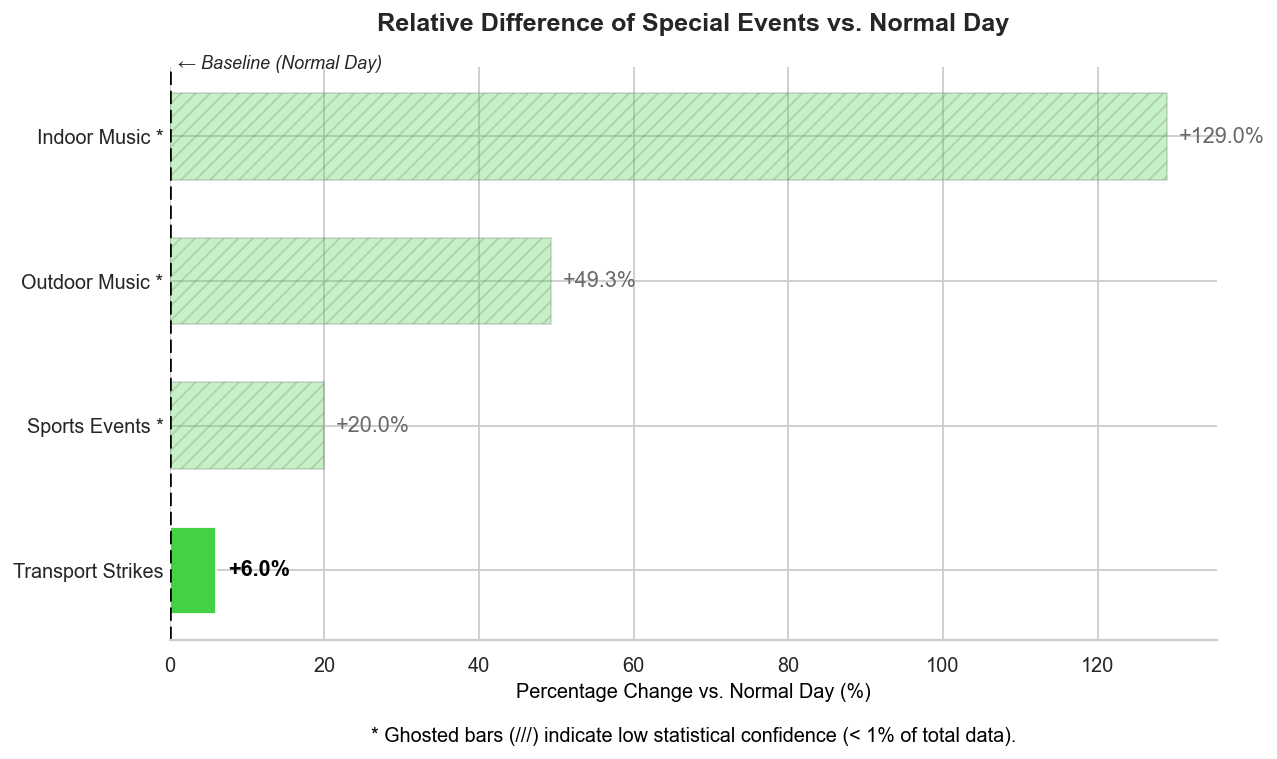

In [114]:
total_obs = len(prediction_data)

sports_obs = prediction_data['is_sport_event'].sum()
outdoor_obs = prediction_data['is_outdoor_music'].sum()
indoor_obs = prediction_data['is_indoor_music'].sum()
strike_obs = prediction_data['is_strike'].sum()

baseline_mask = (
    (prediction_data['is_sport_event'] == 0) & 
    (prediction_data['is_outdoor_music'] == 0) & 
    (prediction_data['is_indoor_music'] == 0) &
    (prediction_data['is_strike'] == 0) 
)
normal_obs = baseline_mask.sum()

baseline_avg = prediction_data[baseline_mask]['count_rescaled'].mean()
sports_avg = prediction_data[prediction_data['is_sport_event'] == 1]['count_rescaled'].mean()
outdoor_avg = prediction_data[prediction_data['is_outdoor_music'] == 1]['count_rescaled'].mean()
indoor_avg = prediction_data[prediction_data['is_indoor_music'] == 1]['count_rescaled'].mean()
strike_avg = prediction_data[prediction_data['is_strike'] == 1]['count_rescaled'].mean()

summary_table = pd.DataFrame({
    "Condition": ["Normal Day", "Sports Event", "Outdoor Music", "Indoor Music", "Transport Strike"],
    "Total 2hr Intervals": [normal_obs, sports_obs, outdoor_obs, indoor_obs, strike_obs],
})

summary_table["% of Total Year"] = (summary_table["Total 2hr Intervals"] / total_obs) * 100
summary_table["% of Total Year"] = summary_table["% of Total Year"].map("{:.1f}%".format)
summary_table = summary_table.sort_values("Total 2hr Intervals", ascending=False)

print("==========================================")
print("       DATA CONTEXT: EVENT FREQUENCY      ")
print("==========================================")
print(summary_table.to_string(index=False))
print("==========================================\n")

def calc_lift(event_avg, base_avg):
    if pd.isna(event_avg) or pd.isna(base_avg) or base_avg == 0:
        return 0
    return ((event_avg - base_avg) / base_avg) * 100

impact_data = pd.DataFrame({
    'Event Type': ['Sports Events', 'Outdoor Music', 'Indoor Music', 'Transport Strikes'],
    'Observations': [sports_obs, outdoor_obs, indoor_obs, strike_obs],
    'Impact (%)': [
        calc_lift(sports_avg, baseline_avg),
        calc_lift(outdoor_avg, baseline_avg),
        calc_lift(indoor_avg, baseline_avg),
        calc_lift(strike_avg, baseline_avg)
    ]
})

impact_data['% of Year'] = (impact_data['Observations'] / total_obs) * 100
impact_data = impact_data.sort_values('Impact (%)')
colors = [color_red if x < 0 else color_green for x in impact_data['Impact (%)']]
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(impact_data['Event Type'], impact_data['Impact (%)'], color=colors, height=0.6)

new_y_labels = []

for i, bar in enumerate(bars):
    pct = impact_data.iloc[i]['% of Year']
    event_name = impact_data.iloc[i]['Event Type']
    
    if pct < 1.0:
        bar.set_alpha(0.3)               
        bar.set_hatch('///')             
        bar.set_edgecolor('gray')        
        new_y_labels.append(f"{event_name} *") 
    else:
        new_y_labels.append(event_name)

ax.set_yticks(range(len(new_y_labels)))
ax.set_yticklabels(new_y_labels)

ax.axvline(0, color='black', linewidth=2, linestyle='--')
ax.text(1, len(impact_data)-0.5, '← Baseline (Normal Day)', va='center', fontstyle='italic', fontsize=10)
ax.set_title("Relative Difference of Special Events vs. Normal Day", pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel("Percentage Change vs. Normal Day (%)\n\n* Ghosted bars (///) indicate low statistical confidence (< 1% of total data).", 
              fontsize=11, color='black')

sns.despine(left=True)
ax.tick_params(axis='y', length=0, labelsize=11)

for i, bar in enumerate(bars):
    width = bar.get_width()
    label_x_pos = width + 1.5 if width > 0 else width - 1.5
    ha = 'left' if width > 0 else 'right'
    text_color = 'dimgray' if impact_data.iloc[i]['% of Year'] < 1.0 else 'black'
    font_weight = 'normal' if impact_data.iloc[i]['% of Year'] < 1.0 else 'bold'
    ax.text(
        label_x_pos, 
        bar.get_y() + bar.get_height() / 2, 
        f'{width:+.1f}%', 
        va='center', 
        ha=ha, 
        fontweight=font_weight,
        color=text_color
    )

plt.tight_layout()
plt.show()